# ĐỒ ÁN: Kiểm định giả thuyết

### Bài nộp của Nhóm 6

Bài tập này tiến hành **kiểm định giả thuyết ngày lễ (holiday)**, ví dụ 24/12 và 31/12 có ảnh hưởng đến doanh số của các sản phẩm hay không?

Lưu ý: Kiểm định ở nhiều cấp độ:

- Toàn bộ mặt hàng

- Một nhóm mặt hàng (cat_l1, cat_l2, cat_l3, cat)

- Một mặt hàng duy nhất (cấp độ SKU)

Các nhóm:

- Phân chia nhiệm vụ trên sheet báo cáo tiến độ hàng tuần.

- Nộp báo cáo kiểm định (dùng 2 công cụ trực quan + thống kê).



---

Trước tiên, ta cần import những thư viện cần thiết

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

Và scan dữ liệu parquet item và transaction.

In [2]:
transactions_path = './transactions-202411-to-202412.parquet'
items_path = './items.parquet'

trans_lf = pl.scan_parquet(transactions_path)
items_lf = pl.scan_parquet(items_path)

print(trans_lf.limit(5).collect())
print(items_lf.limit(5).collect())

trans_lf.select(pl.col("channel").cast(pl.Utf8).unique().sort()).collect()

shape: (5, 8)
┌─────────────┬─────────────┬─────────────┬──────────┬─────────┬─────────────┬──────────┬──────────┐
│ customer_id ┆ item_id     ┆ price       ┆ channel  ┆ payment ┆ updated_dat ┆ location ┆ quantity │
│ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---     ┆ e           ┆ ---      ┆ ---      │
│ i32         ┆ str         ┆ decimal[38, ┆ str      ┆ str     ┆ ---         ┆ i32      ┆ i32      │
│             ┆             ┆ 4]          ┆          ┆         ┆ datetime[μs ┆          ┆          │
│             ┆             ┆             ┆          ┆         ┆ ]           ┆          ┆          │
╞═════════════╪═════════════╪═════════════╪══════════╪═════════╪═════════════╪══════════╪══════════╡
│ 6680595     ┆ 60330000000 ┆ 169000.0000 ┆ In-Store ┆ VietQR  ┆ 2024-12-29  ┆ 181      ┆ 1        │
│             ┆ 53          ┆             ┆          ┆         ┆ 17:37:10.41 ┆          ┆          │
│             ┆             ┆             ┆          ┆         ┆ 0           

channel
str
"""Android"""
"""CRM Partner"""
"""Call"""
"""Chat"""
"""In-Store"""
"""Không xác định"""
"""SPE"""
"""Web"""
"""Wholesale"""


# Kiểm định ở gốc độ toàn bộ mặt hàng

Đầu tiên ta sẽ thử plot doanh số (số lượng sản phẩm bán được) theo ngày

Trước hết, ta thấy rằng trong dữ liệu không có data của ngày 31/12. Ta sẽ mặc định doanh số bán được ngày 31 bằng 0.

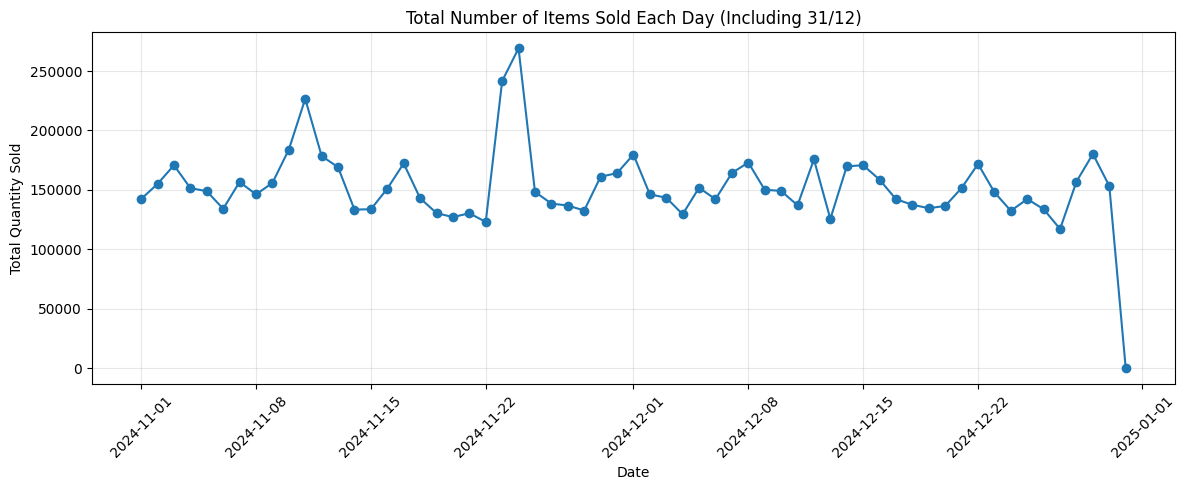

In [3]:
daily_sales_df = (
    trans_lf
    .with_columns(
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date")
    )
    .group_by("date")
    .agg(
        pl.sum("quantity").alias("total_quantity")
    )
    .sort("date")
    .collect()
)

# Tạo đầy đủ dải ngày từ 2024-11-01 đến 2024-12-31
full_dates = pl.DataFrame({
    "date": pl.date_range(
        start=pl.date(2024, 11, 1),
        end=pl.date(2024, 12, 31),
        interval="1d",
        eager=True
    )
})

# Join để chắc chắn có cả ngày 31/12
daily_sales_full_df = (
    full_dates
    .join(daily_sales_df, on="date", how="left")
    .with_columns(
        pl.col("total_quantity").fill_null(0)
    )
    .sort("date")
)

plt.figure(figsize=(12, 5))
plt.plot(
    daily_sales_full_df["date"].to_list(),
    daily_sales_full_df["total_quantity"].to_list(),
    marker="o"
)
plt.title("Total Number of Items Sold Each Day (Including 31/12)")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ta có thể giải thích việc thiếu dữ liệu của ngày 31 theo hai cách:
- TH1: Ngày 31/12 không được thu thập giữ liệu
- TH2: Ngày 31/12 được thu thập giữ liệu nhưng không có transaction nào diễn ra, điều này có thể là do vào ngày lễ đấy tất cả các địa điểm bán hàng của doanh nghiệp được nghỉ

Xét ở trường TH2 nếu vấn đề nằm ở việc tất cả các địa điểm đều nghỉ thì rõ ràng ngày 31/12 chắc chắn đã ảnh hưởng tới doanh số của tất cả sản phẩm vì từ bảng trên ta có thể thấy doanh số ngày 31/12 trở về 0, còn những ngày trước đó thì bình thường.

Do đó, ở đây ta sẽ chỉ xét TH1 "ngày 31/12 không được thu thập giữ liệu", và sẽ tập trung xem xét những ngày lễ khác

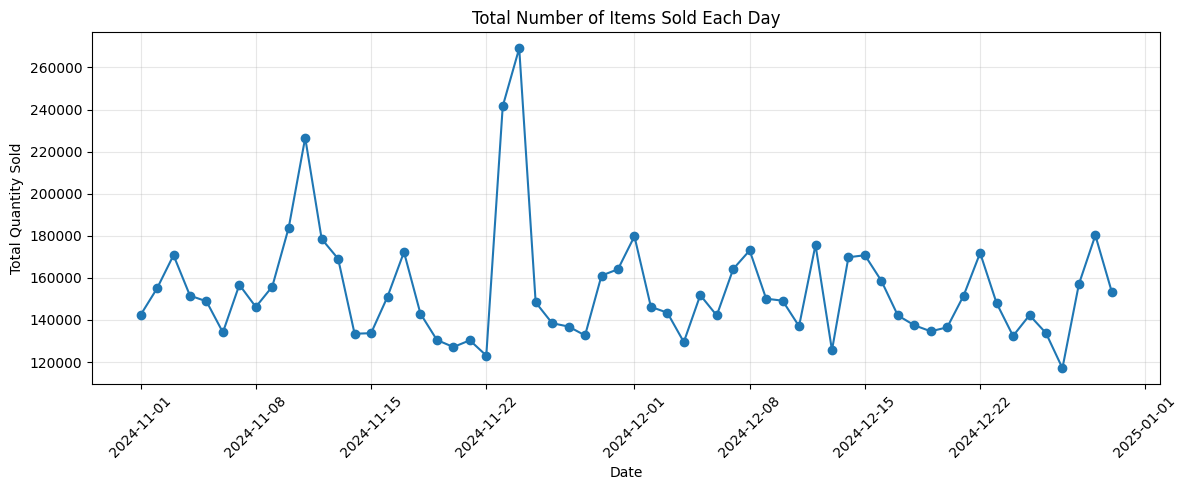

In [4]:
daily_sales_df = (
    trans_lf
    .with_columns(
        pl.col("updated_date").dt.date().alias("date")
    )
    .group_by("date")
    .agg(
        pl.sum("quantity").alias("total_quantity")
    )
    .sort("date")
    .collect()
)

plt.figure(figsize=(12, 5))
plt.plot(
    daily_sales_df["date"].to_list(),
    daily_sales_df["total_quantity"].to_list(),
    marker="o"
)
plt.title("Total Number of Items Sold Each Day")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Một chút quan sát trên dữ liệu
- Ta có thể quan sát từ plot là ngày 23/11 và 24/11 có số lượng hàng được bán tăng triệt để, qua một chút tìm hiểu thì có thể là do các chương trình giảm giá black friday, thường chạy từ ngày 23-29/11

- Tiếp theo, ta cũng có thể thấy những ngày 9-13 của tháng 11 cũng có số lượng hàng bán được tăng lên, qua chút tìm hiểu thì hiện tường này có thể là do các chương trình liên quan đến ngày 11/11, là ngày mà các nền tảng bán hàng online thường tổ chức nhiều chương trình giảm giá sâu.

- Ta cũng có thể thấy một chút giảm vào ngày 23/12 và 24/12 và tăng vào những ngày còn lại gần cuối năm, điều này có thể lần lượt do Noel mọi người có xu hướng đi chơi nhiều, nên không mua nhiều; và tăng là do gần cuối năm.

Nhưng đây vẫn chỉ là những giả thuyết, ta vẫn chưa thể biết rõ lí do tại sao lại có các khoảng tăng giảm doanh số như thế.

Để tiếp tục có cái nhìn rõ hơn về doanh số, ta sẽ plot doanh số theo tuần, và theo rolling sum của 3 và 7 ngày gần nhất.

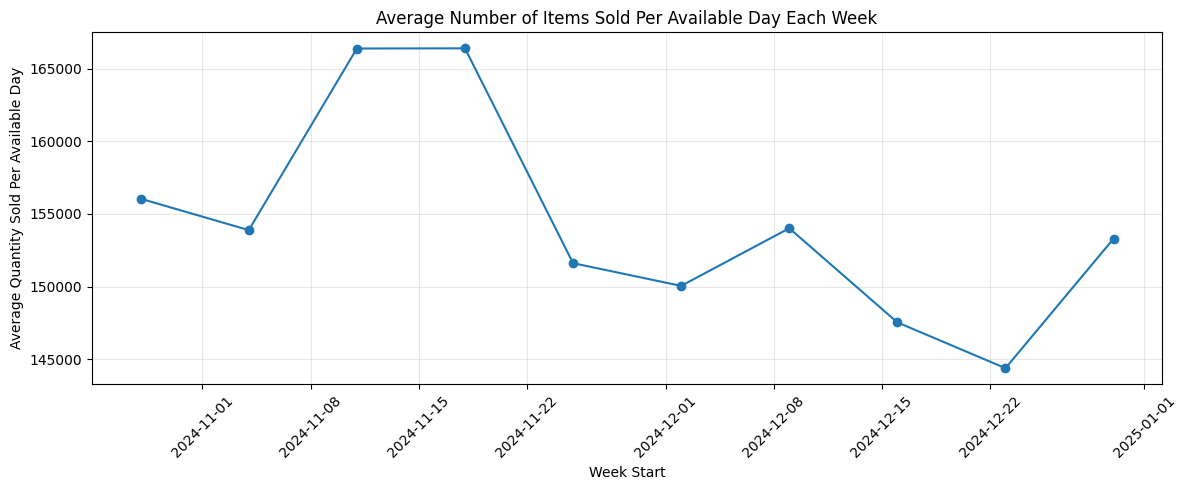

In [5]:
weekly_avg_sales_df = (
    trans_lf
    .with_columns(
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date")
    )
    .with_columns(
        pl.col("date").dt.truncate("1w").alias("week_start")
    )
    .group_by("week_start")
    .agg(
        pl.sum("quantity").alias("total_quantity"),
        pl.n_unique("date").alias("available_days")
    )
    .with_columns(
        (pl.col("total_quantity") / pl.col("available_days")).alias("avg_quantity_per_available_day")
    )
    .sort("week_start")
    .collect()
)

plt.figure(figsize=(12, 5))
plt.plot(
    weekly_avg_sales_df["week_start"].to_list(),
    weekly_avg_sales_df["avg_quantity_per_available_day"].to_list(),
    marker="o"
)
plt.title("Average Number of Items Sold Per Available Day Each Week")
plt.xlabel("Week Start")
plt.ylabel("Average Quantity Sold Per Available Day")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ở bảng theo tuần, ta có thể thấy được sự tăng đáng kể vào những ngày 9-13 tháng 11, những ngày 23-24 tháng 11 và giảm vào đúng dịp noel xong đó tăng trở lại.

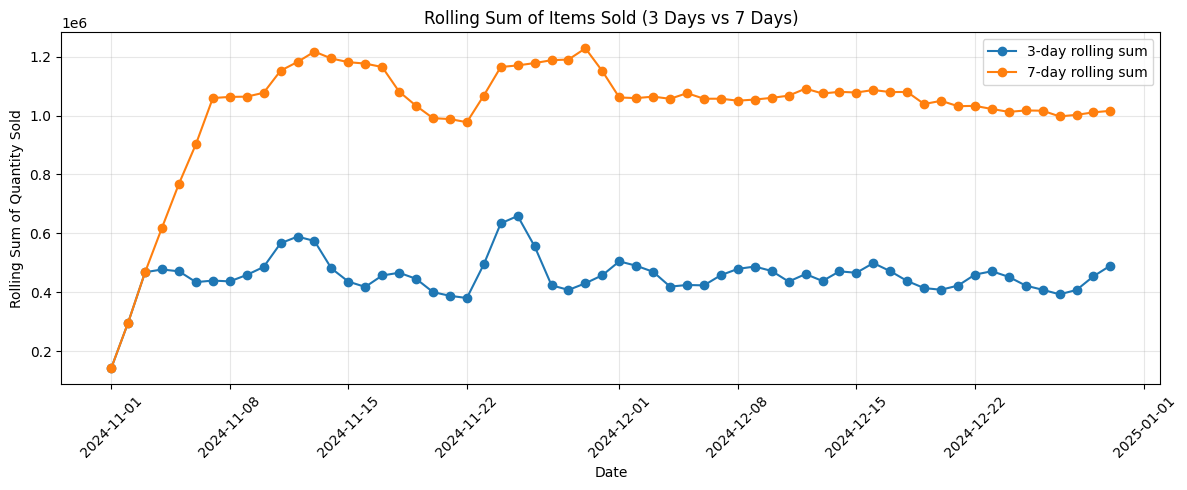

In [6]:
import pandas as pd

daily_sales_df = (
    trans_lf
    .with_columns(
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date")
    )
    .group_by("date")
    .agg(
        pl.sum("quantity").alias("total_quantity")
    )
    .sort("date")
    .collect()
)

daily_sales_pd = daily_sales_df.to_pandas()
daily_sales_pd["date"] = pd.to_datetime(daily_sales_pd["date"])

daily_sales_pd["rolling_3d_sum"] = daily_sales_pd["total_quantity"].rolling(window=3, min_periods=1).sum()
daily_sales_pd["rolling_7d_sum"] = daily_sales_pd["total_quantity"].rolling(window=7, min_periods=1).sum()

plt.figure(figsize=(12, 5))
plt.plot(
    daily_sales_pd["date"],
    daily_sales_pd["rolling_3d_sum"],
    marker="o",
    label="3-day rolling sum"
)
plt.plot(
    daily_sales_pd["date"],
    daily_sales_pd["rolling_7d_sum"],
    marker="o",
    label="7-day rolling sum"
)
plt.title("Rolling Sum of Items Sold (3 Days vs 7 Days)")
plt.xlabel("Date")
plt.ylabel("Rolling Sum of Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Bảng này, tuy khoảng thời gian cuối năm không nhìn rõ nhưng ở hai khoảng thời gian vào những ngày 9-13 tháng 11, những ngày 23-24 tháng 11, ta vẫn có thể thấy sự tăng đáng kể so với những ngày khác.

Như vậy, qua 2 plot ta vẫn có thể thấy ảnh hưởng của 2 giai đoạn tăng doanh số đấy, vào những ngày 9-13 tháng 11, những ngày 23-24 tháng 11, và những ngày cuối năm, để có cái nhìn rõ hơn nữa, ta sẽ tiếp tục phân tích dưới góc độ từng nhóm mặt hàng, xem hiện tượng này có tiếp tục xảy ra

Để thuận tiện hơn, ta sẽ gọi:
- khoảng 9-13 tháng 11 là khoảng A
- khoảng 22-25 tháng 11 là khoảng B
- khoảng những ngày cuối năm là khoảng C

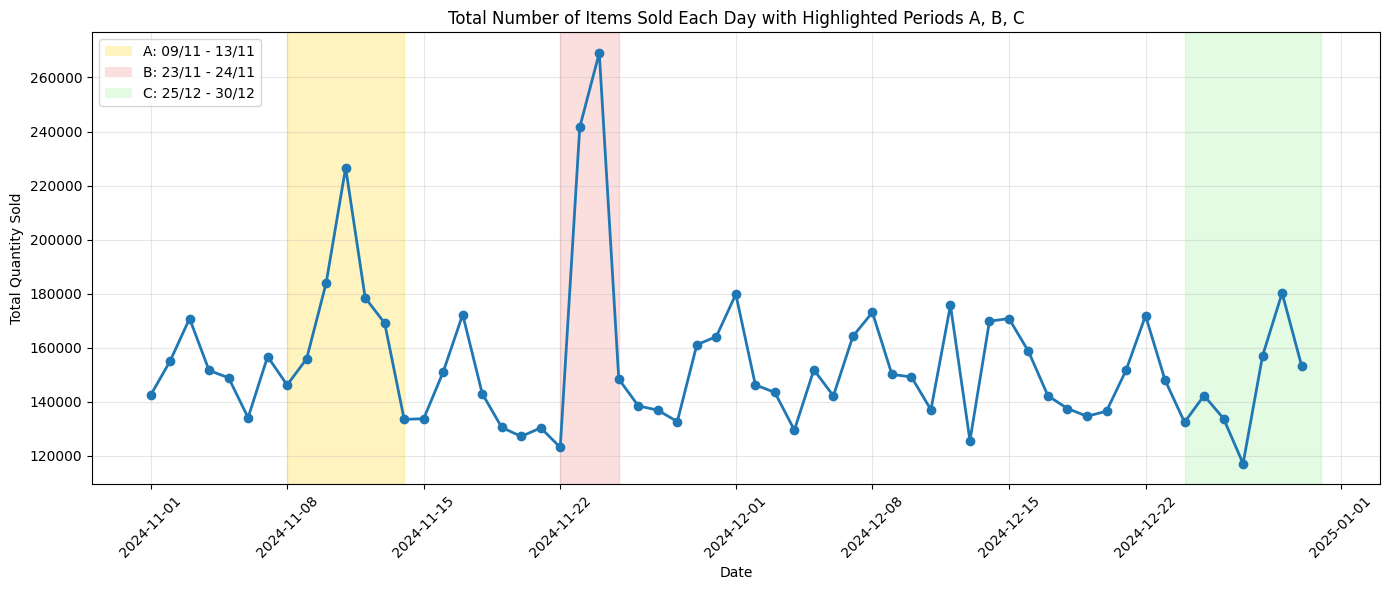

In [7]:
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from datetime import date, timedelta

# Daily sales
daily_sales_df = (
    trans_lf
    .with_columns(
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date")
    )
    .group_by("date")
    .agg(
        pl.sum("quantity").alias("total_quantity")
    )
    .sort("date")
    .collect()
)

# Full date range only up to 30/12
full_dates = pl.DataFrame({
    "date": pl.date_range(
        start=date(2024, 11, 1),
        end=date(2024, 12, 30),
        interval="1d",
        eager=True
    )
})

daily_sales_full_df = (
    full_dates
    .join(daily_sales_df, on="date", how="left")
    .with_columns(
        pl.col("total_quantity").fill_null(0)
    )
    .sort("date")
)

x = daily_sales_full_df["date"].to_list()
y = daily_sales_full_df["total_quantity"].to_list()

# Define periods
A_start, A_end = date(2024, 11, 9),  date(2024, 11, 13)
B_start, B_end = date(2024, 11, 23), date(2024, 11, 24)
C_start, C_end = date(2024, 12, 25), date(2024, 12, 30)

fig, ax = plt.subplots(figsize=(14, 6))

# Main line
ax.plot(x, y, marker="o", linewidth=2, label="Daily total quantity sold")

# Shade regions
ax.axvspan(A_start - timedelta(days=1), A_end + timedelta(days=1), color="gold", alpha=0.25)
ax.axvspan(B_start - timedelta(days=1), B_end + timedelta(days=1), color="lightcoral", alpha=0.25)
ax.axvspan(C_start - timedelta(days=1), C_end + timedelta(days=1), color="lightgreen", alpha=0.25)

# Legend box for A, B, C
legend_handles = [
    Patch(facecolor="gold", edgecolor="none", alpha=0.25, label="A: 09/11 - 13/11"),
    Patch(facecolor="lightcoral", edgecolor="none", alpha=0.25, label="B: 23/11 - 24/11"),
    Patch(facecolor="lightgreen", edgecolor="none", alpha=0.25, label="C: 25/12 - 30/12"),
]

ax.legend(handles=legend_handles, loc="upper left", frameon=True)

ax.set_title("Total Number of Items Sold Each Day with Highlighted Periods A, B, C")
ax.set_xlabel("Date")
ax.set_ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kiểm định ở gốc độ các nhóm mặt hàng


Đầu tiên ta sẽ chuẩn bị trước một số hàm để dễ dàng hơn cho quá trình visualize

In [8]:
# Adjust these if your item master uses different column names
ITEM_ID_COL = "item_id"
CAT_L1_COL = "category_l1"
CAT_L2_COL = "category_l2"
CAT_L3_COL = "category_l3"

items_meta_lf = (
    items_lf
    .select([
        pl.col(ITEM_ID_COL).cast(pl.Utf8).alias("item_id"),
        pl.col(CAT_L1_COL).cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l1"),
        pl.col(CAT_L2_COL).cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l2"),
        pl.col(CAT_L3_COL).cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l3"),
    ])
    .unique(subset=["item_id"])
)

sales_lf = (
    trans_lf
    .with_columns([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date"),
        pl.col("quantity").cast(pl.Int64).alias("quantity"),
        pl.col("price").cast(pl.Float64).alias("price"),
    ])
    .join(items_meta_lf, on="item_id", how="left")
    .with_columns([
        pl.col("category_l1").fill_null("UNKNOWN"),
        pl.col("category_l2").fill_null("UNKNOWN"),
        pl.col("category_l3").fill_null("UNKNOWN"),
        (pl.col("quantity") * pl.col("price")).alias("revenue"),
    ])
)

def get_category_totals(level="category_l1"):
    return (
        sales_lf
        .group_by(level)
        .agg([
            pl.sum("quantity").alias("total_quantity"),
            pl.sum("revenue").alias("total_revenue"),
            pl.n_unique("item_id").alias("n_items"),
            pl.n_unique("date").alias("n_active_days"),
        ])
        .sort("total_quantity", descending=True)
        .collect()
        .to_pandas()
    )

def get_daily_category_sales(level="category_l1"):
    return (
        sales_lf
        .group_by(["date", level])
        .agg([
            pl.sum("quantity").alias("daily_quantity"),
            pl.sum("revenue").alias("daily_revenue"),
        ])
        .sort(["date", level])
        .collect()
        .to_pandas()
    )

def get_weekly_category_sales(level="category_l1"):
    return (
        sales_lf
        .with_columns(
            pl.col("date").dt.truncate("1w").alias("week_start")
        )
        .group_by(["week_start", level])
        .agg([
            pl.sum("quantity").alias("weekly_quantity"),
            pl.sum("revenue").alias("weekly_revenue"),
        ])
        .sort(["week_start", level])
        .collect()
        .to_pandas()
    )

Ban đầu, ta sẽ thử xem những category nào có số lượng sản phẩm bán nhiều nhất

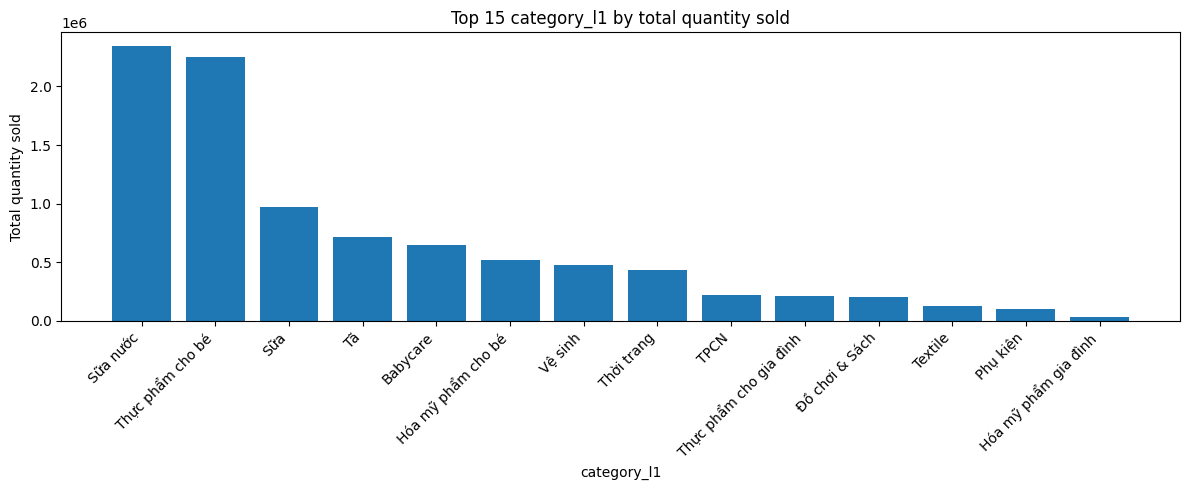

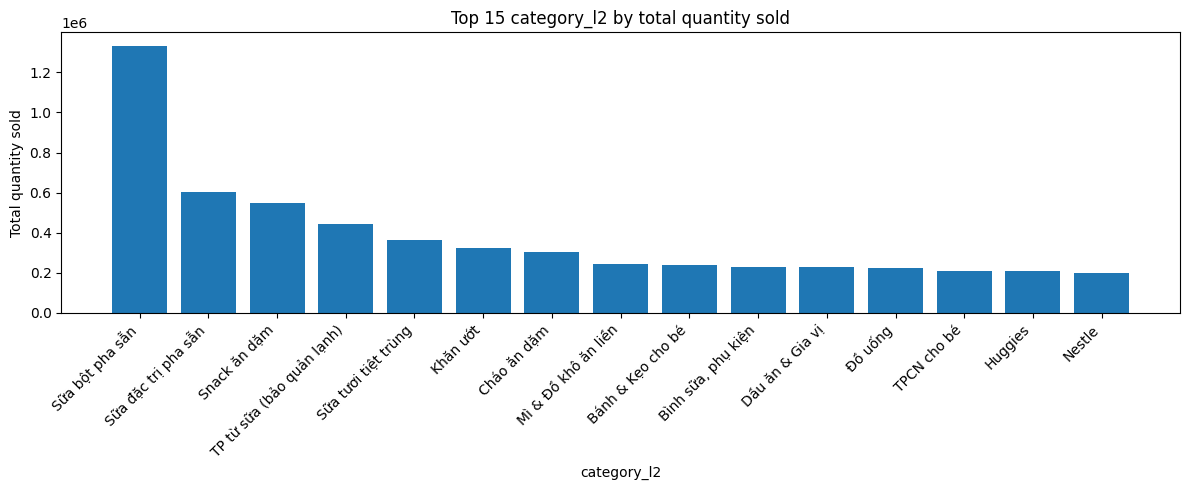

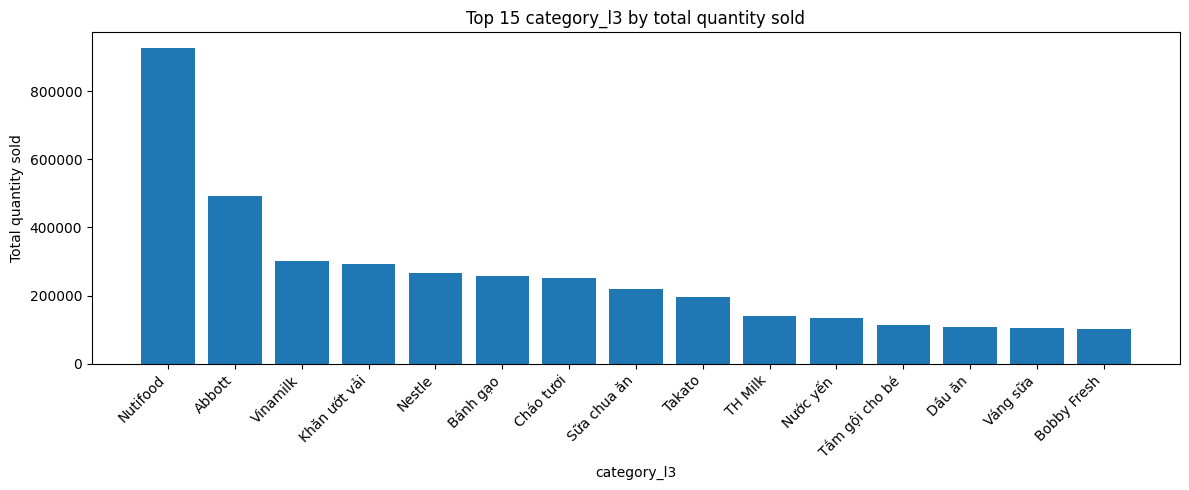

In [9]:
def plot_top_categories_bar(level="category_l1", top_n=15):
    df = get_category_totals(level).head(top_n)

    plt.figure(figsize=(12, 5))
    plt.bar(df[level].astype(str), df["total_quantity"])
    plt.title(f"Top {top_n} {level} by total quantity sold")
    plt.xlabel(level)
    plt.ylabel("Total quantity sold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_top_categories_bar("category_l1", top_n=15)
plot_top_categories_bar("category_l2", top_n=15)
plot_top_categories_bar("category_l3", top_n=15)

Tiếp tục, ta sẽ plot số lượng hàng bán được của 8 loại hàng bán chạy nhất mỗi ngày, xét cả category l1, l2 và l3

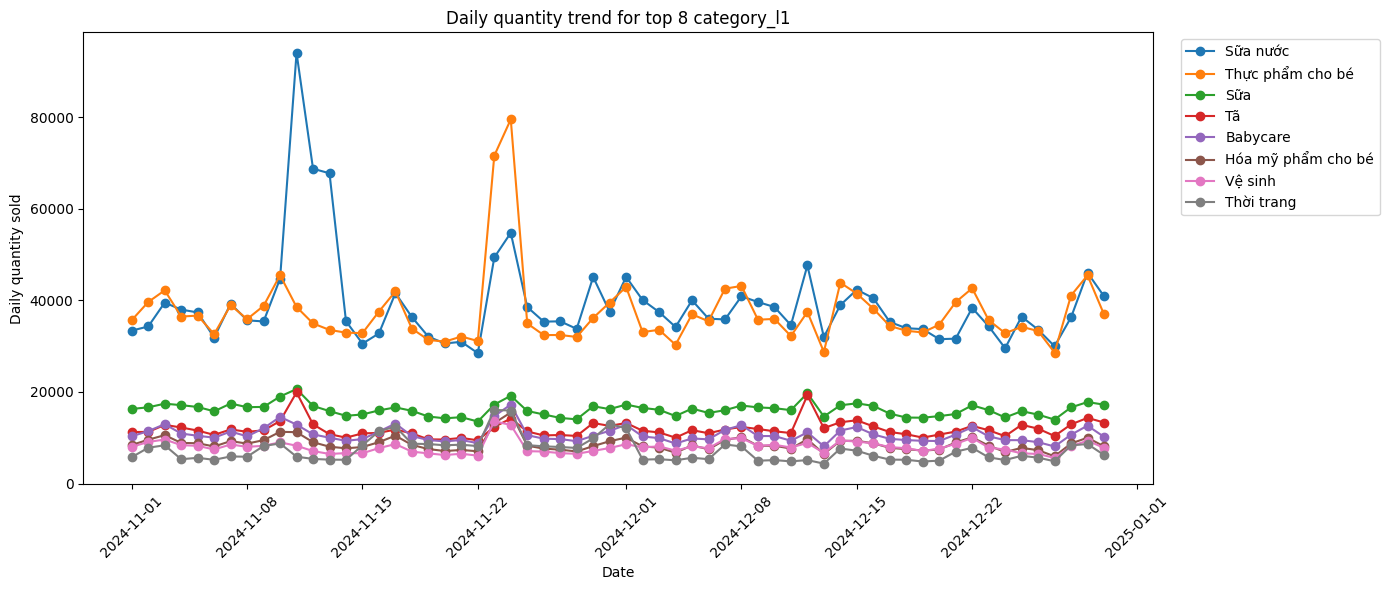

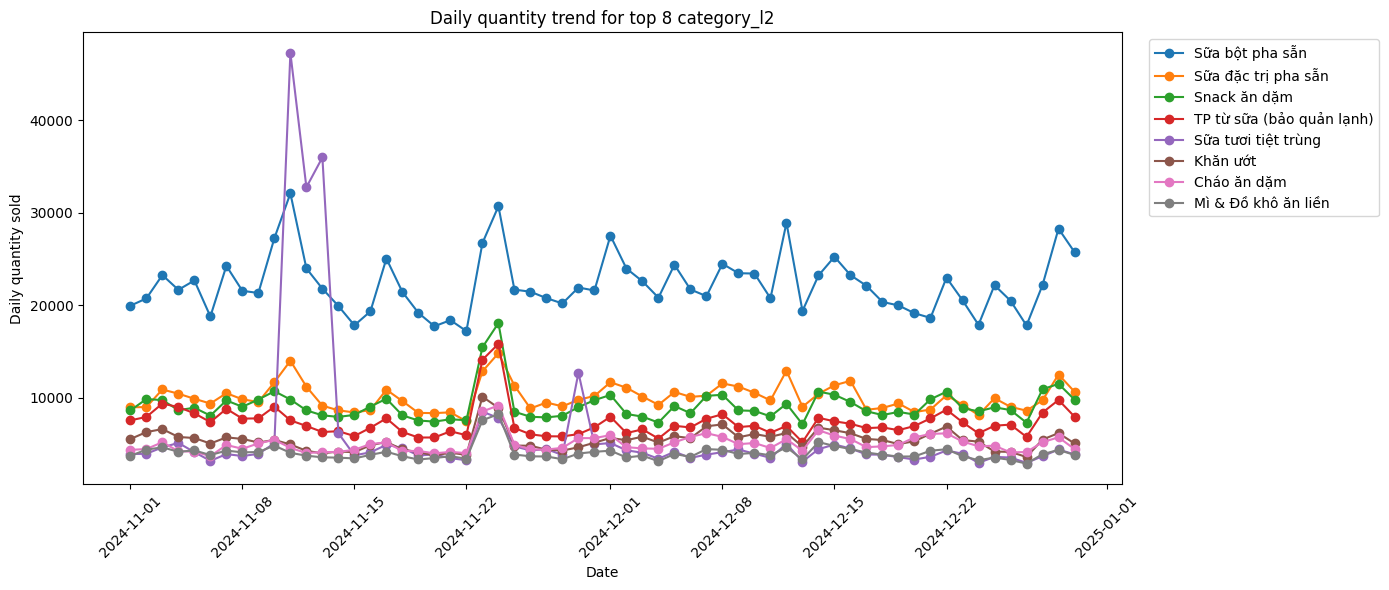

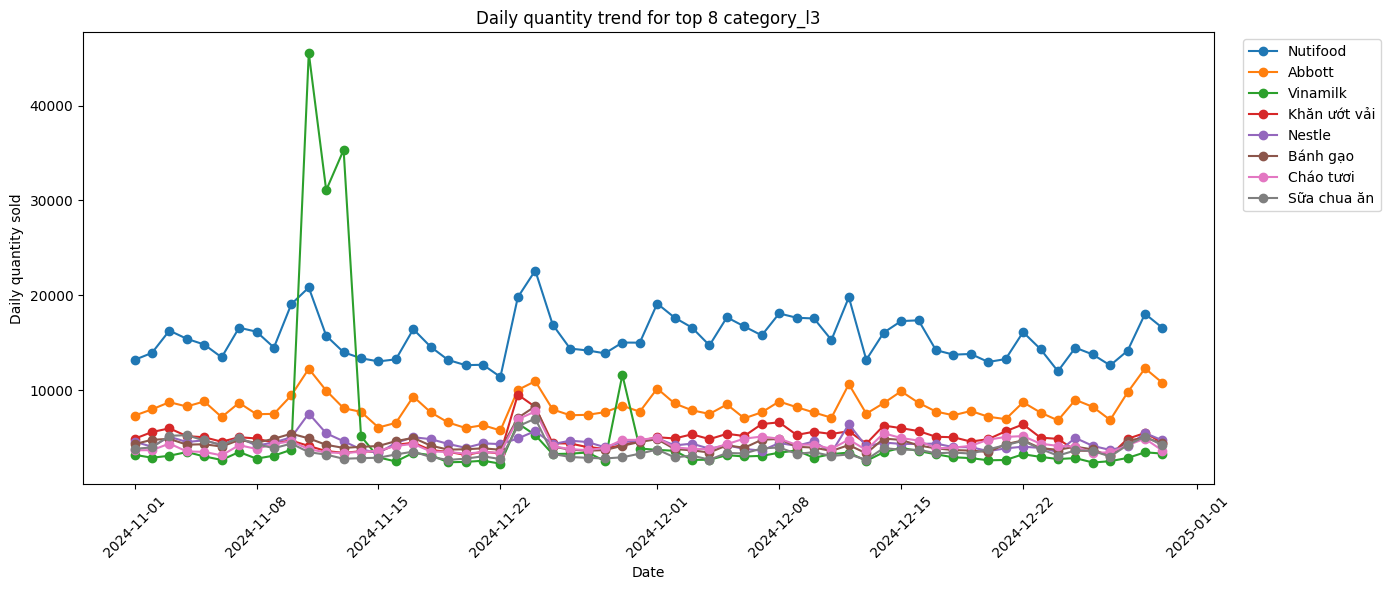

In [10]:
def plot_top_categories_daily_trend(level="category_l1", top_k=8):
    totals = get_category_totals(level).head(top_k)
    top_categories = totals[level].tolist()

    daily_df = get_daily_category_sales(level)
    daily_df["date"] = pd.to_datetime(daily_df["date"])
    daily_df = daily_df[daily_df[level].isin(top_categories)]

    plt.figure(figsize=(14, 6))
    for cat in top_categories:
        sub = daily_df[daily_df[level] == cat].sort_values("date")
        plt.plot(sub["date"], sub["daily_quantity"], marker="o", label=str(cat))

    plt.title(f"Daily quantity trend for top {top_k} {level}")
    plt.xlabel("Date")
    plt.ylabel("Daily quantity sold")
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_top_categories_daily_trend("category_l1", top_k=8)
plot_top_categories_daily_trend("category_l2", top_k=8)
plot_top_categories_daily_trend("category_l3", top_k=8)

### Qua plot này ta có một số cái nhìn thú vị hơn:
- với Category_l1, khoảng A có doanh số chủ yếu đến từ các sản phẩm sữa nước, khoảng B có doanh số chủ yếu từ các sản phẩm thực phẩm cho bé và sữa nước
- với Category_l2, ta có thể thấy doanh số sữa tươi tiệt trùng nhảy lên ở khoảng A, và sữa bột pha sẵn cũng có xu hướng tăng doanh số ở cả 3 khoảng A, B, C, hơn nữa khoảng B nữ cũngacó phân bổ doanh số khá đồng đều giữa top 8 category l2
- còn với Category_l3, ta thấy khoảng A chủ yếu là các sản phẩm của vinamilk, còn nutrifood và abbott đều đóng góp vào cả 3 khoảng A, B, C, thú vị hơn với khoảng B, ta có thể thấy đa số loại sản phẩm đều đóng góp doanh số khá đồng đều

### Vậy ta có thể đoán những ngày lễ ảnh hưởng đến các khoảng A, B, C:
- khoảng A khớp với giai đoạn sale trên các nền tảng online (như tiktok shop, shopee,...)
- khoảng B khớp với ngày lễ black friday, mặc dù black friday là vào ngày 29/11 đa số chương trình sẽ bắt đầu trước 1-2 tuần cho khách hàng mua sắm
- khoảng C khớp với những ngày lễ cuối năm (như giáng sinh 24-25/12, những ngày cận năm mới 1/1)

Để tiếp tục test giả định khoảng A có doanh số tăng nhờ các nền tảng online (channel android, ios, web), ta sẽ plot theo các channel online để xem doanh số qua các ngày

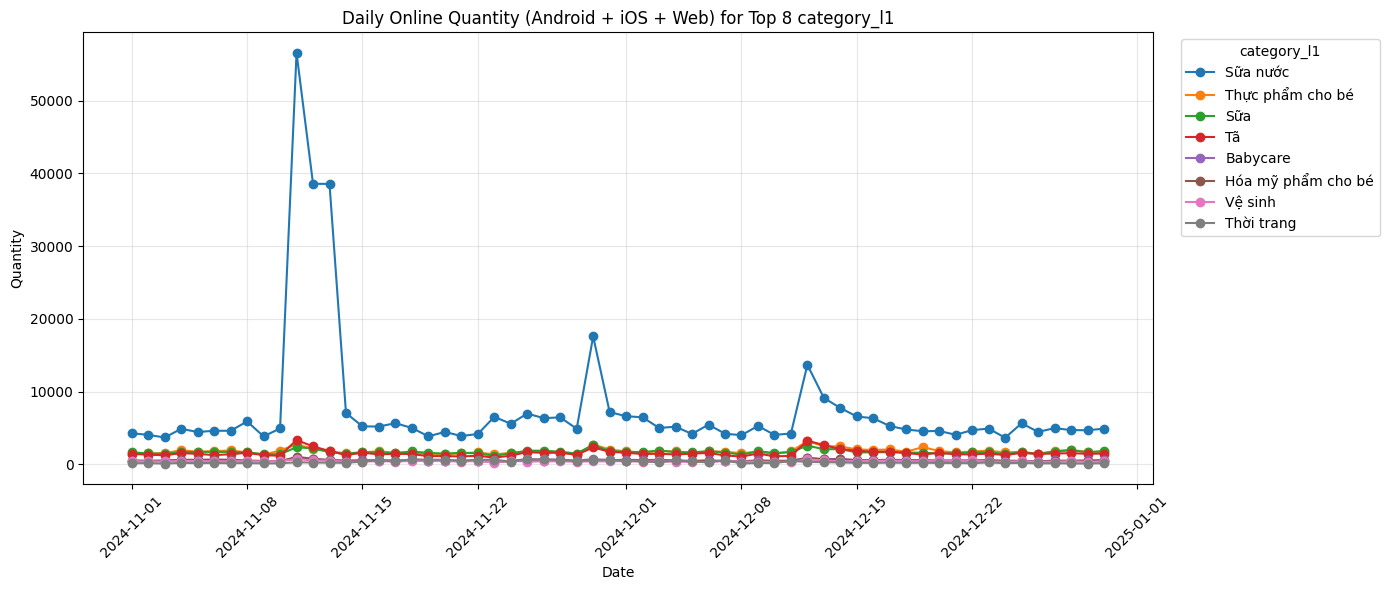

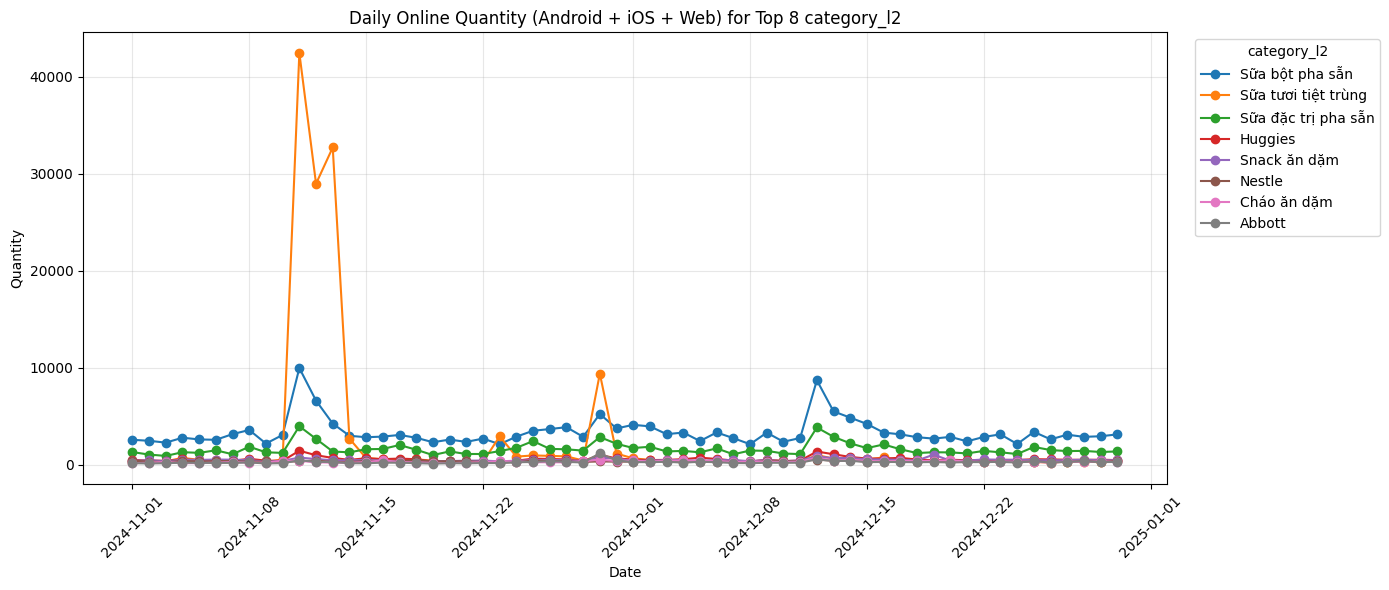

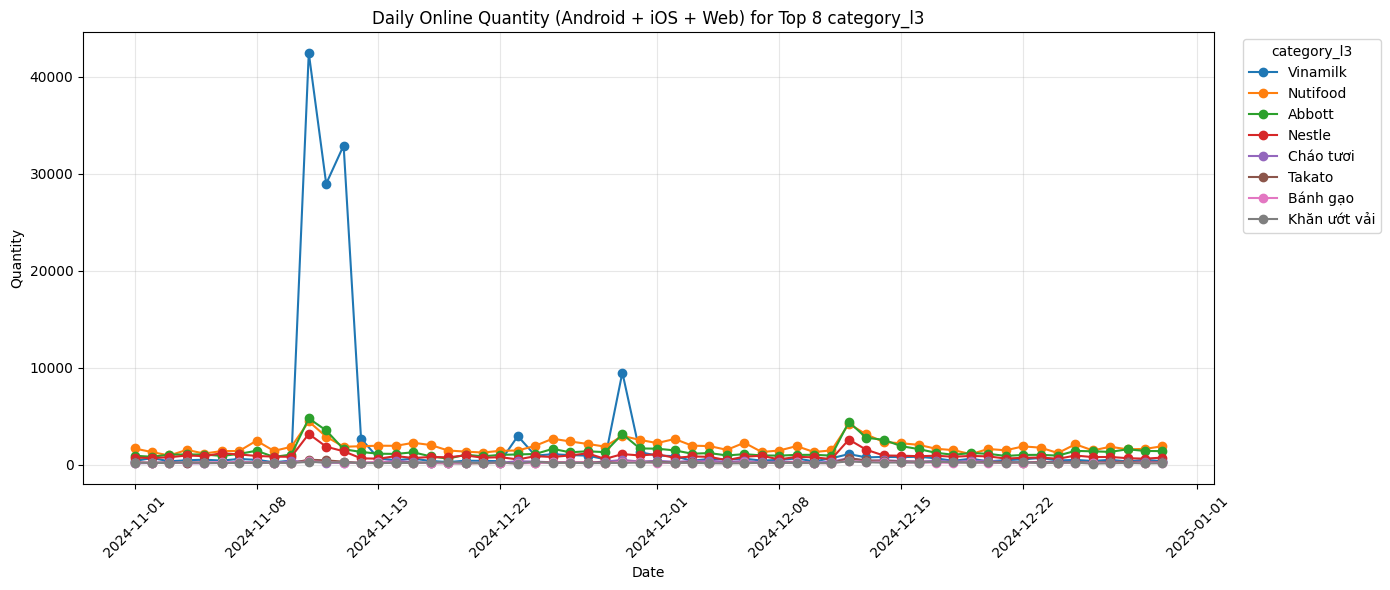

In [11]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

ONLINE_CHANNELS = ["Android", "iOS", "Web"]
TOP_K = 8

items_lf = pl.scan_parquet('./items.parquet')

items_meta_lf = (
    items_lf
    .select([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("category_l1").cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l1"),
        pl.col("category_l2").cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l2"),
        pl.col("category_l3").cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l3"),
    ])
    .unique(subset=["item_id"])
)

sales_lf = (
    trans_lf
    .with_columns([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date"),
        pl.col("quantity").cast(pl.Int64).alias("quantity"),
        pl.col("channel").cast(pl.Utf8).alias("channel"),
    ])
    .join(items_meta_lf, on="item_id", how="left")
    .with_columns([
        pl.col("category_l1").fill_null("UNKNOWN"),
        pl.col("category_l2").fill_null("UNKNOWN"),
        pl.col("category_l3").fill_null("UNKNOWN"),
    ])
    .filter(pl.col("channel").is_in(ONLINE_CHANNELS))
)

def plot_daily_online_top_categories_same_plot(level, top_k=8):
    top_cats = (
        sales_lf
        .group_by(level)
        .agg(pl.sum("quantity").alias("total_quantity"))
        .sort("total_quantity", descending=True)
        .head(top_k)
        .collect()
        .get_column(level)
        .to_list()
    )

    daily_df = (
        sales_lf
        .filter(pl.col(level).is_in(top_cats))
        .group_by(["date", level])
        .agg(pl.sum("quantity").alias("daily_quantity"))
        .sort(["date", level])
        .collect()
        .to_pandas()
    )

    daily_df["date"] = pd.to_datetime(daily_df["date"])
    full_dates = pd.date_range(daily_df["date"].min(), daily_df["date"].max(), freq="D")

    plt.figure(figsize=(14, 6))

    for cat in top_cats:
        sub = daily_df[daily_df[level] == cat].copy()
        sub = (
            sub.set_index("date")
               .reindex(full_dates)
               .fillna(0)
               .rename_axis("date")
               .reset_index()
        )
        plt.plot(sub["date"], sub["daily_quantity"], marker="o", label=str(cat))

    plt.title(f"Daily Online Quantity (Android + iOS + Web) for Top {top_k} {level}")
    plt.xlabel("Date")
    plt.ylabel("Quantity")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(title=level, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_daily_online_top_categories_same_plot("category_l1", top_k=TOP_K)
plot_daily_online_top_categories_same_plot("category_l2", top_k=TOP_K)
plot_daily_online_top_categories_same_plot("category_l3", top_k=TOP_K)

 Như ta có thể thấy, khi xét các channel online (android, ios, web), thì khoảng A có doanh số tăng vượt trội và khoảng B cũng có doanh số tăng kha khá, có nghĩa răng doanh số tăng trong khoảng A là nhờ vào các chương trình trên các nền tảng bán hàng online (như tiktok, shopee,...), và khoảng B cũng có ảnh hưởng của các chương trình black friday trên các nền tảng online

 để tiếp tục test giả thuyết này thì ta có thể plot theo các channel khác (instore, call,...) để xem rõ hơn

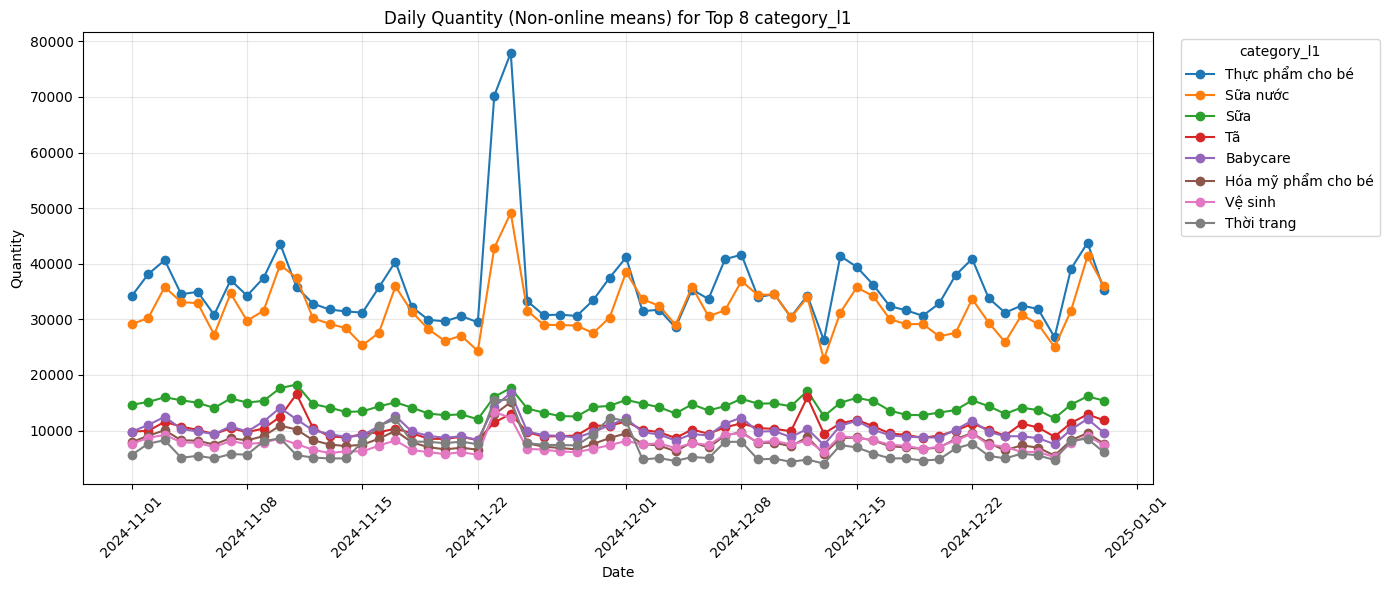

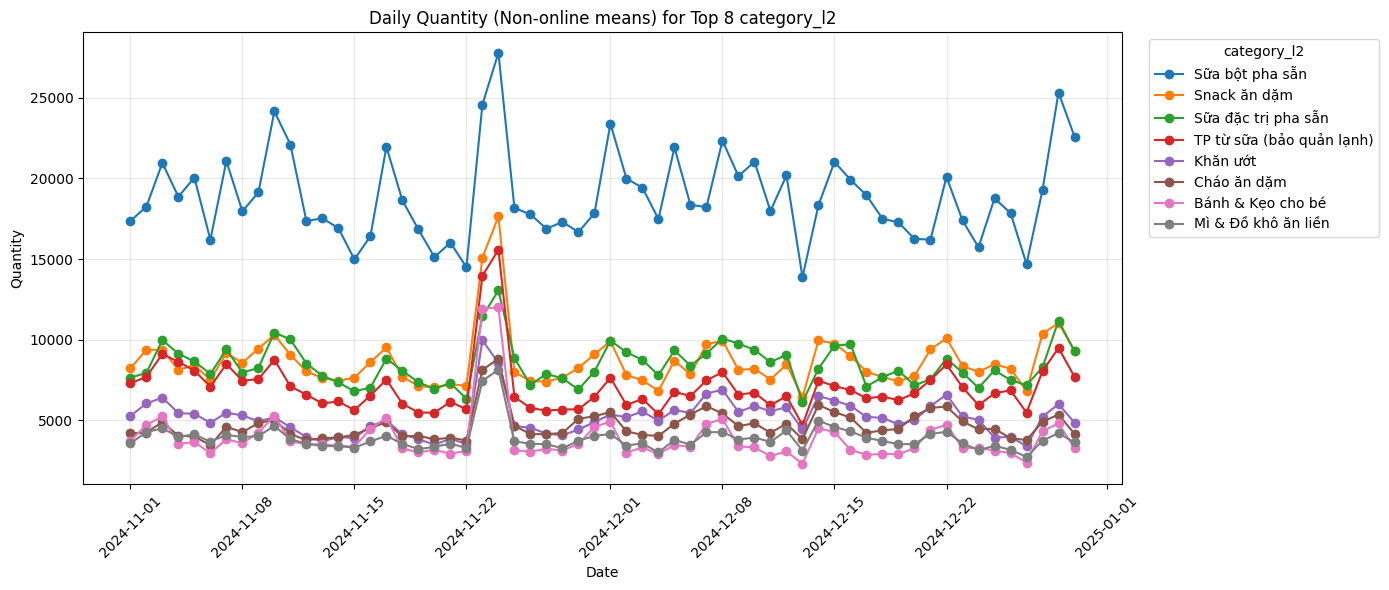

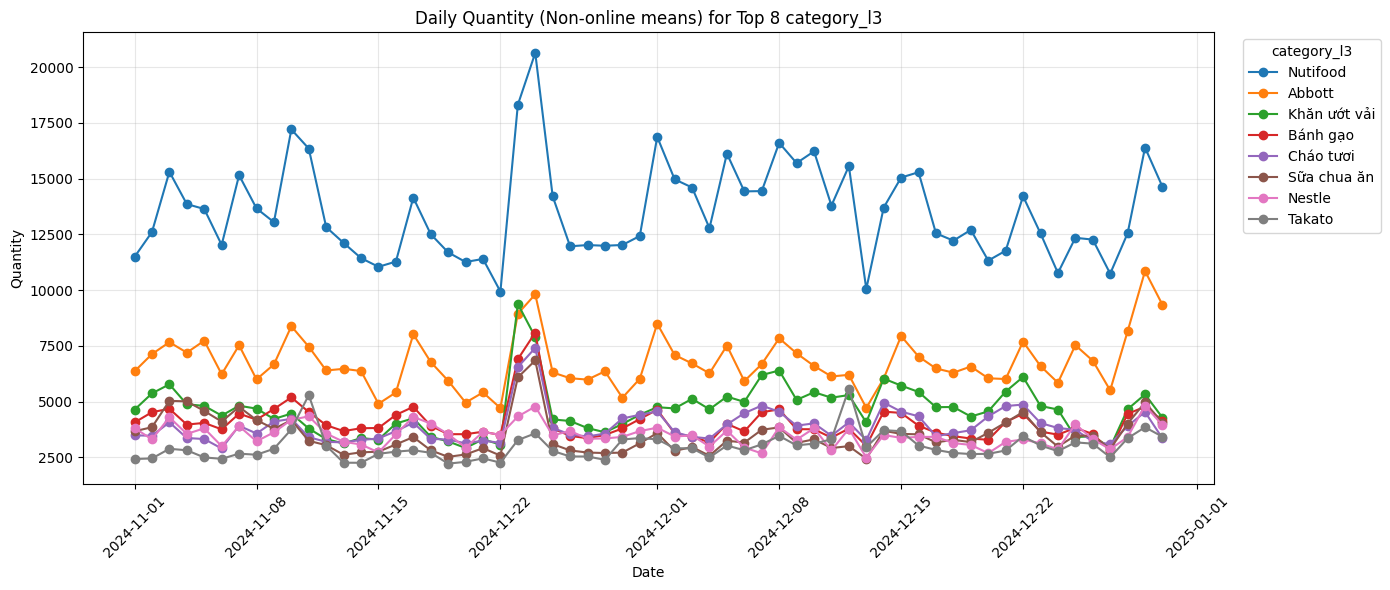

In [12]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

ONLINE_CHANNELS = ["CRM Partner", "Call", "Chat", "In-Store",
"Wholesale", "SPE"]
TOP_K = 8

items_lf = pl.scan_parquet('./items.parquet')

items_meta_lf = (
    items_lf
    .select([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("category_l1").cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l1"),
        pl.col("category_l2").cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l2"),
        pl.col("category_l3").cast(pl.Utf8).fill_null("UNKNOWN").alias("category_l3"),
    ])
    .unique(subset=["item_id"])
)

sales_lf = (
    trans_lf
    .with_columns([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date"),
        pl.col("quantity").cast(pl.Int64).alias("quantity"),
        pl.col("channel").cast(pl.Utf8).alias("channel"),
    ])
    .join(items_meta_lf, on="item_id", how="left")
    .with_columns([
        pl.col("category_l1").fill_null("UNKNOWN"),
        pl.col("category_l2").fill_null("UNKNOWN"),
        pl.col("category_l3").fill_null("UNKNOWN"),
    ])
    .filter(pl.col("channel").is_in(ONLINE_CHANNELS))
)

def plot_daily_online_top_categories_same_plot(level, top_k=8):
    top_cats = (
        sales_lf
        .group_by(level)
        .agg(pl.sum("quantity").alias("total_quantity"))
        .sort("total_quantity", descending=True)
        .head(top_k)
        .collect()
        .get_column(level)
        .to_list()
    )

    daily_df = (
        sales_lf
        .filter(pl.col(level).is_in(top_cats))
        .group_by(["date", level])
        .agg(pl.sum("quantity").alias("daily_quantity"))
        .sort(["date", level])
        .collect()
        .to_pandas()
    )

    daily_df["date"] = pd.to_datetime(daily_df["date"])
    full_dates = pd.date_range(daily_df["date"].min(), daily_df["date"].max(), freq="D")

    plt.figure(figsize=(14, 6))

    for cat in top_cats:
        sub = daily_df[daily_df[level] == cat].copy()
        sub = (
            sub.set_index("date")
               .reindex(full_dates)
               .fillna(0)
               .rename_axis("date")
               .reset_index()
        )
        plt.plot(sub["date"], sub["daily_quantity"], marker="o", label=str(cat))

    plt.title(f"Daily Quantity (Non-online means) for Top {top_k} {level}")
    plt.xlabel("Date")
    plt.ylabel("Quantity")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(title=level, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_daily_online_top_categories_same_plot("category_l1", top_k=TOP_K)
plot_daily_online_top_categories_same_plot("category_l2", top_k=TOP_K)
plot_daily_online_top_categories_same_plot("category_l3", top_k=TOP_K)

ở đây ta thấy doanh số trổi dậy sẽ tập trung nhiều hơn vào khoảng B và khoảng C, cũng hợp lí bởi sở gĩ những sự kiện như black friday và những ngày cuối năm thì sẽ thúc đẩy khách hàng mua sắm nhiều hơn ở những cửa hàng vật lý

ta cũng có thể thấy rằng khoảng A thì sẽ có doanh số đồng đều hơn, ngày 11/11 chủ yếu là có những chương trình trên các nền tảng online, chứ ko được phổ cập ở các cửa hàng vật lý nhiều bằng các sự kiện như black friday hay ngày lễ cuối năm

# Kiểm định ở gốc độ một hàng duy nhất (cấp độ SKU)

Tương tự với nhóm hàng, ta sẽ plot top 15 các sản phẩm bán được nhiều nhất.

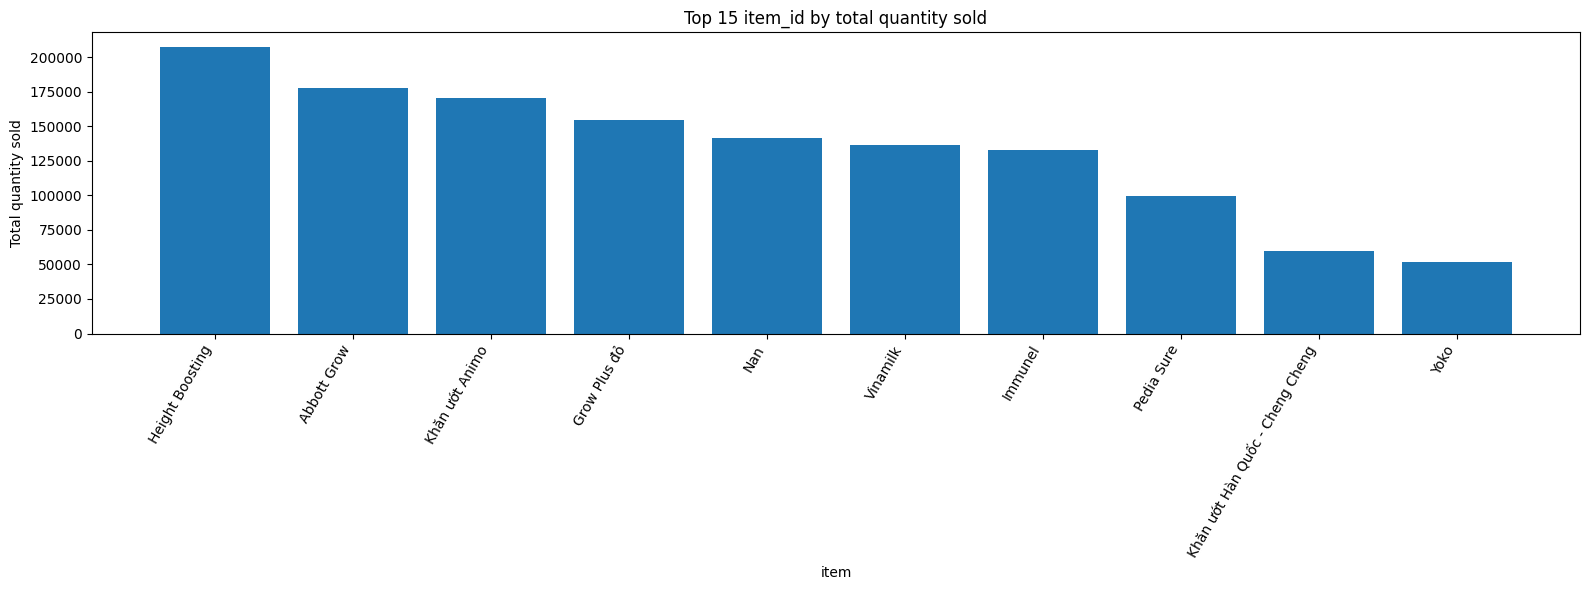

In [13]:
def get_item_totals_with_info():
    item_info_lf = (
        items_lf
        .select([
            pl.col("item_id").cast(pl.Utf8),
            pl.col("brand").cast(pl.Utf8),
            pl.col("manufacturer").cast(pl.Utf8),
            pl.col("category_l1").cast(pl.Utf8),
            pl.col("category_l2").cast(pl.Utf8),
            pl.col("category_l3").cast(pl.Utf8),
            pl.col("category").cast(pl.Utf8),
        ])
        .unique(subset=["item_id"])
    )

    return (
        trans_lf
        .with_columns([
            pl.col("item_id").cast(pl.Utf8),
            pl.col("quantity").cast(pl.Int64),
        ])
        .join(item_info_lf, on="item_id", how="left")
        .group_by([
            "item_id", "brand", "manufacturer",
            "category_l1", "category_l2", "category_l3", "category"
        ])
        .agg(pl.sum("quantity").alias("total_quantity"))
        .sort("total_quantity", descending=True)
        .collect()
        .to_pandas()
    )

def plot_top_items_bar_with_info(top_n=15):
    df = get_item_totals_with_info().head(top_n).copy()

    df["label"] = (
        df["category"].fillna("UNKNOWN").astype(str)
    )

    plt.figure(figsize=(16, 6))
    plt.bar(df["label"], df["total_quantity"])
    plt.title(f"Top {top_n} item_id by total quantity sold")
    plt.xlabel("item")
    plt.ylabel("Total quantity sold")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()
plot_top_items_bar_with_info(top_n=15)

Top item bán nhiều nhất:
shape: (15, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ item_id    ┆ brand      ┆ manufactur ┆ category_ ┆ category_ ┆ category_ ┆ category  ┆ total_qua │
│ ---        ┆ ---        ┆ er         ┆ l1        ┆ l2        ┆ l3        ┆ ---       ┆ ntity     │
│ str        ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ str       ┆ ---       │
│            ┆            ┆ str        ┆ str       ┆ str       ┆ str       ┆           ┆ i64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 7176000000 ┆ GrowPLUS+  ┆ Công ty Cổ ┆ Sữa nước  ┆ Sữa bột   ┆ Nutifood  ┆ Height    ┆ 207641    │
│ 002        ┆ Height     ┆ Phần Thực  ┆           ┆ pha sẵn   ┆           ┆ Boosting  ┆           │
│            ┆ Boosting   ┆ Phẩm Dinh… ┆           ┆           ┆           ┆           ┆           │
│ 2005000000 ┆ Abbott     ┆ Không xác  ┆ Sữa nước  

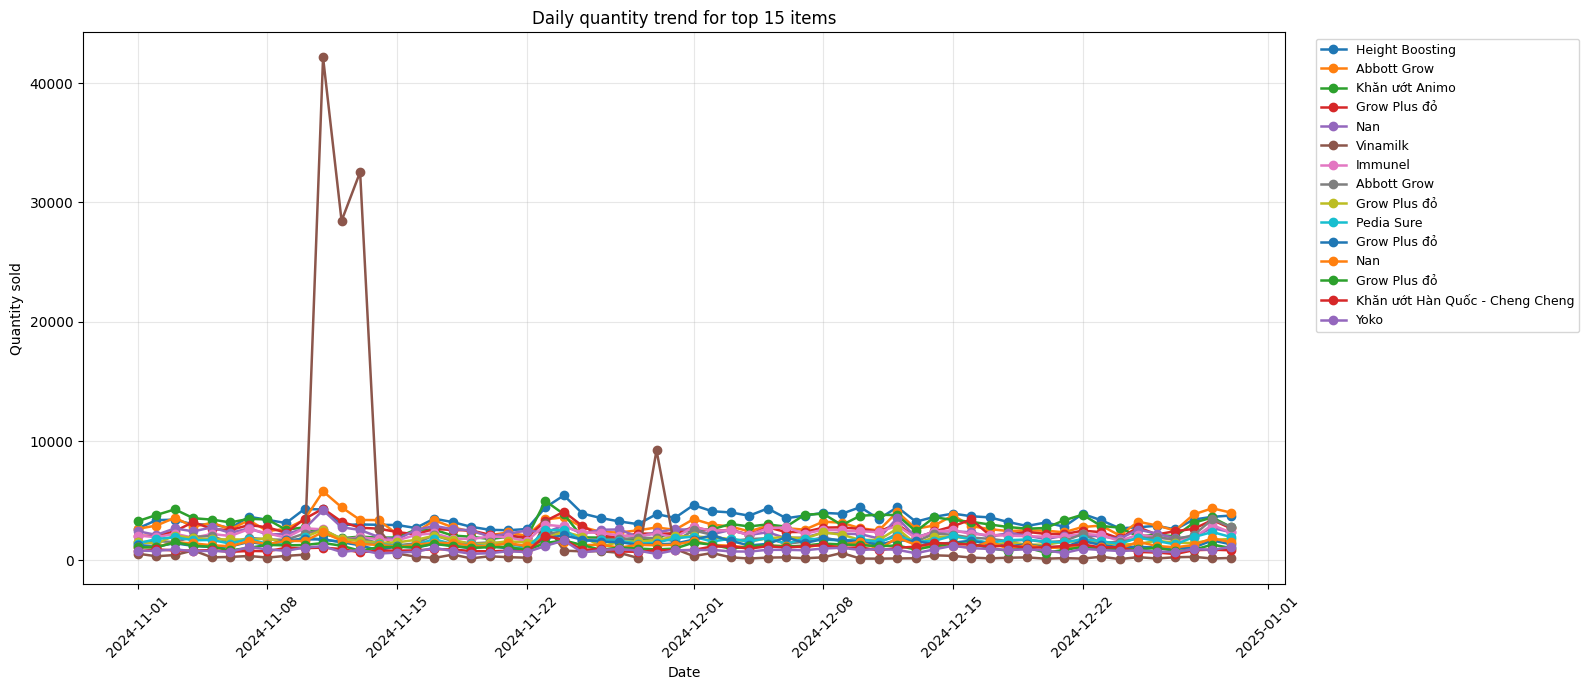

In [14]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

TOP_K = 15

item_info_lf = (
    items_lf
    .select([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("brand").cast(pl.Utf8).alias("brand"),
        pl.col("manufacturer").cast(pl.Utf8).alias("manufacturer"),
        pl.col("category_l1").cast(pl.Utf8).alias("category_l1"),
        pl.col("category_l2").cast(pl.Utf8).alias("category_l2"),
        pl.col("category_l3").cast(pl.Utf8).alias("category_l3"),
        pl.col("category").cast(pl.Utf8).alias("category"),
    ])
    .unique(subset=["item_id"])
)

sales_lf = (
    trans_lf
    .with_columns([
        pl.col("item_id").cast(pl.Utf8).alias("item_id"),
        pl.col("updated_date").cast(pl.Datetime).dt.date().alias("date"),
        pl.col("quantity").cast(pl.Int64).alias("quantity"),
        pl.col("channel").cast(pl.Utf8).alias("channel"),
    ])
    .join(item_info_lf, on="item_id", how="left")
)

# 3) Top K item bán nhiều nhất theo tổng quantity
top_k_df = (
    sales_lf
    .group_by([
        "item_id", "brand", "manufacturer",
        "category_l1", "category_l2", "category_l3", "category"
    ])
    .agg(pl.sum("quantity").alias("total_quantity"))
    .sort("total_quantity", descending=True)
    .head(TOP_K)
    .collect()
)

print("Top item bán nhiều nhất:")
print(top_k_df)

top_items = top_k_df["item_id"].to_list()

# 4) Tạo label đẹp cho legend
label_map = {}
for row in top_k_df.to_dicts():
    item_id = row["item_id"]
    category = row["category"] if row["category"] is not None else "UnknownCategory"
    label_map[item_id] = category 

# 5) Tính quantity theo ngày cho top K item
daily_item_df = (
    sales_lf
    .filter(pl.col("item_id").is_in(top_items))
    .group_by(["date", "item_id"])
    .agg(pl.sum("quantity").alias("daily_quantity"))
    .sort(["date", "item_id"])
    .collect()
    .to_pandas()
)

daily_item_df["date"] = pd.to_datetime(daily_item_df["date"])

# 6) Pivot để mỗi item là 1 cột
daily_item_table = (
    daily_item_df
    .pivot(index="date", columns="item_id", values="daily_quantity")
    .fillna(0)
    .sort_index()
)

# 7) Fill đầy đủ ngày bị thiếu
full_dates = pd.date_range(
    daily_item_table.index.min(),
    daily_item_table.index.max(),
    freq="D"
)
daily_item_table = daily_item_table.reindex(full_dates).fillna(0)
daily_item_table.index.name = "date"

print("\nBảng quantity theo ngày của top item:")
print(daily_item_table.head())

def plot_item_trend(exception = []):
    plt.figure(figsize=(16, 7))

    for item in top_items:
        if item in exception: 
            continue
        if item in daily_item_table.columns:
            plt.plot(
                daily_item_table.index,
                daily_item_table[item],
                marker="o",
                linewidth=1.8,
                label=label_map[item]
            )

    plt.title(f"Daily quantity trend for top {TOP_K} items")
    plt.xlabel("Date")
    plt.ylabel("Quantity sold")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()
plot_item_trend()

Từ bảng này ta thấy dữ liệu của sữa Vinamilk vào 11/11 bị bán qúa chạy so với phần còn lại. Ta sẽ tạm bỏ qua Vinamilk để có bảng line chart dễ nhìn hơn.

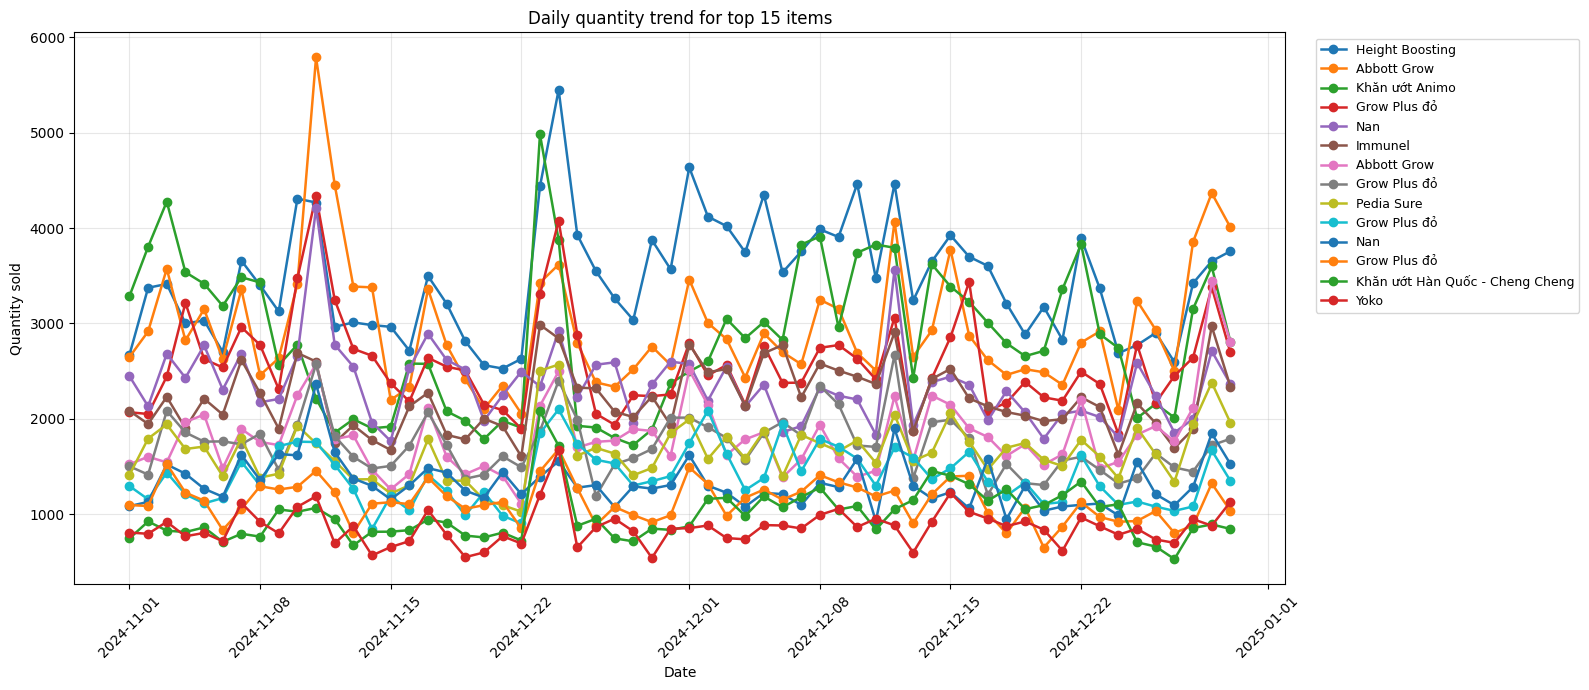

In [15]:
plot_item_trend(exception=[str(1215000000002)])

Từ plot có thể thấy 11/11, 23/11, 24/11, 12/12 và những ngày cuối năm có sự tăng so với những ngày khác. Để cụ thể hơn, ta sẽ đi vào sản phẩm chi tiết.

In [16]:
def plot_item(item_id):
    item_df = (
        sales_lf
        .filter(pl.col("item_id") == str(item_id))
        .group_by("date")
        .agg(pl.sum("quantity").alias("daily_quantity"))
        .sort("date")
        .collect()
        .to_pandas()
    )

    if item_df.empty:
        print(f"Item {item_id} not found.")
        return

    # lấy category của item này
    category_name = (
        sales_lf
        .filter(pl.col("item_id") == str(item_id))
        .select("category")
        .drop_nulls()
        .unique()
        .collect()
        .to_pandas()
    )

    if len(category_name) > 0:
        category_label = category_name.iloc[0]["category"]
    else:
        category_label = f"item_{item_id}"

    item_df["date"] = pd.to_datetime(item_df["date"])

    full_dates = pd.date_range(item_df["date"].min(), item_df["date"].max(), freq="D")
    item_df = (
        item_df
        .set_index("date")
        .reindex(full_dates)
        .fillna(0)
        .rename_axis("date")
        .reset_index()
    )

    plt.figure(figsize=(14, 6))
    plt.plot(
        item_df["date"],
        item_df["daily_quantity"],
        marker="o",
        label=category_label
    )
    plt.title(f"Daily quantity trend for item {category_label}")
    plt.xlabel("Date")
    plt.ylabel("Quantity sold")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(title="category")
    plt.tight_layout()
    plt.show()

Đầu tiên là Vinamilk (item_id = 1215000000002)

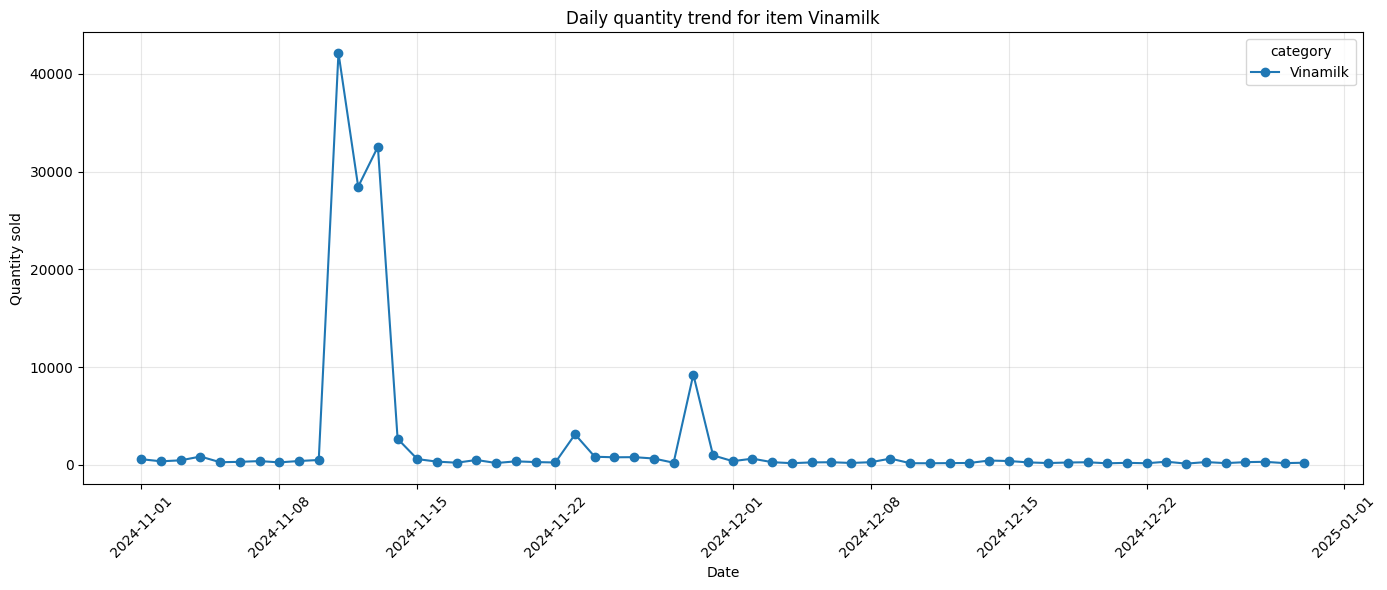

In [17]:
plot_item("1215000000002")

Có thể thấy ngày 11/11 có đợt sale nên nhu cầu của mọi người đã mua nhiều vào ngày này. Ngoài ra doanh số bán ít nhất ghi nhật được là vào đúng 24/12

In [18]:
# Show min quantity day for the item
def show_min_quantity_day(item_id):
    item_df = (
        sales_lf
        .filter(pl.col("item_id") == str(item_id))
        .group_by("date")
        .agg(pl.sum("quantity").alias("daily_quantity"))
        .sort("daily_quantity")
        .collect()
        .to_pandas()
    )

    if item_df.empty:
        print(f"Item {item_id} not found.")
        return

    min_row = item_df.iloc[0]
    min_date = min_row["date"]
    min_quantity = min_row["daily_quantity"]

    print(f"Minimum quantity for item {item_id} is {min_quantity} on date {min_date}")
print("\nMinimum quantity day for item 1215000000002:")
show_min_quantity_day("1215000000002")


Minimum quantity day for item 1215000000002:
Minimum quantity for item 1215000000002 is 110 on date 2024-12-24 00:00:00


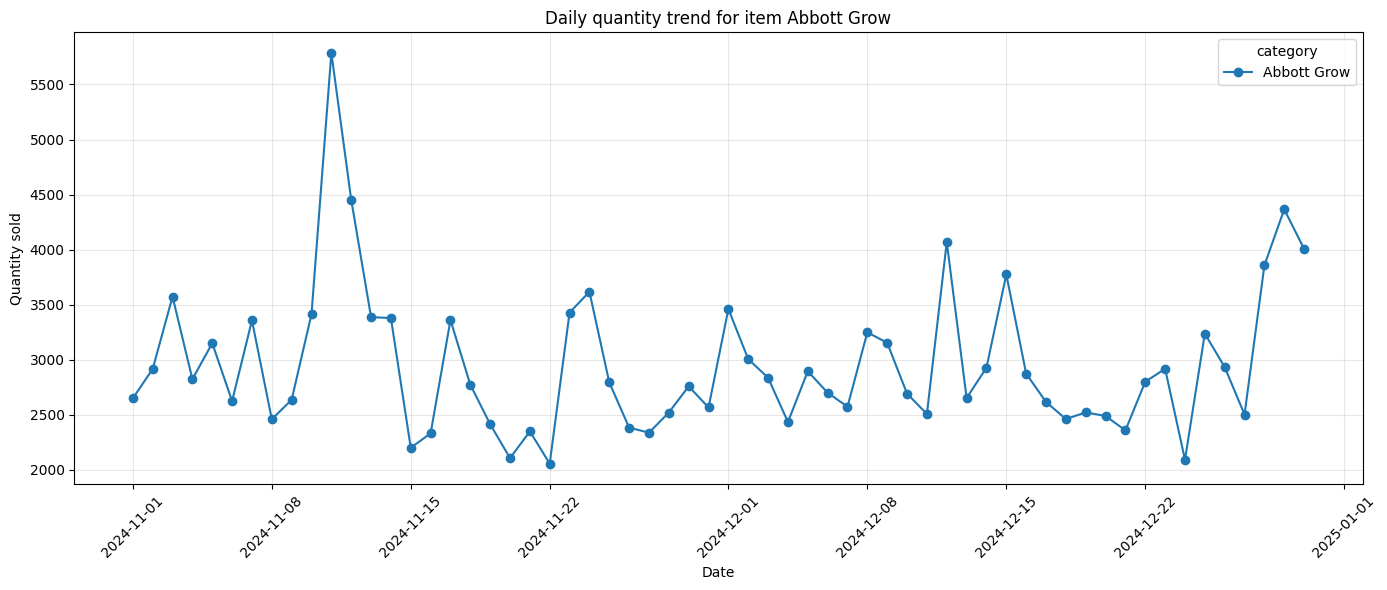

In [56]:
plot_item("2005000000006")

Ở sản phẩm này thì ngoài sự tăng đáng kể vào những dịp 11/11, 12/11 thì ta còn thấy những ngày cuối của năm nhu cầu mua cũng tăng.

### Về kiểm định thống kê

Ta tạo hàm để kiểm tra một ngày lễ nào ấy có là bất thường hay không:

In [19]:
import polars as pl
import pandas as pd
import numpy as np
from math import erf, sqrt

def _normal_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def statistical_check(target_date, item_id=None, compare_mode="same_weekday", two_sided=True):
    target_date = pd.to_datetime(target_date).date()

    base_lf = (
        sales_lf
        .with_columns(pl.col("date").cast(pl.Date))
        .group_by("date")
        .agg(pl.sum("quantity").alias("daily_sales"))
        .sort("date")
    )

    if item_id is not None:
        base_lf = (
            sales_lf
            .filter(pl.col("item_id") == str(item_id))
            .with_columns(pl.col("date").cast(pl.Date))
            .group_by("date")
            .agg(pl.sum("quantity").alias("daily_sales"))
            .sort("date")
        )

    daily = (
        base_lf
        .with_columns([
            pl.col("date").dt.weekday().alias("weekday"),
            pl.col("date").dt.month().alias("month")
        ])
        .collect()
    )

    if daily.filter(pl.col("date") == target_date).height == 0:
        print(f"Không tìm thấy dữ liệu cho ngày {target_date}.")
        return None

    target_val = daily.filter(pl.col("date") == target_date)["daily_sales"][0]
    target_weekday = daily.filter(pl.col("date") == target_date)["weekday"][0]

    if compare_mode == "same_weekday":
        ref = daily.filter(
            (pl.col("date") != target_date) &
            (pl.col("weekday") == target_weekday)
        )
        compare_label = "các ngày cùng thứ"
    elif compare_mode == "weekday_only":
        ref = daily.filter(
            (pl.col("date") != target_date) &
            (pl.col("weekday") < 5)
        )
        compare_label = "các ngày thường (T2-T6)"
    elif compare_mode == "same_month":
        ref = daily.filter(
            (pl.col("date") != target_date) &
            (pl.col("month") == daily.filter(pl.col("date") == target_date)["month"][0])
        )
        compare_label = "các ngày cùng tháng"
    elif compare_mode == "all":
        ref = daily.filter(pl.col("date") != target_date)
        compare_label = "toàn bộ các ngày còn lại"
    else:
        raise ValueError("compare_mode phải là: 'same_weekday', 'weekday_only', 'same_month', hoặc 'all'")

    ref_vals = ref["daily_sales"].to_numpy()

    if len(ref_vals) < 2:
        print("Nhóm đối chứng quá ít dữ liệu để kiểm chứng.")
        return None

    mean_val = ref_vals.mean()
    std_val = ref_vals.std(ddof=1)

    if std_val == 0:
        print("Độ lệch chuẩn của nhóm đối chứng bằng 0, không thể tính z-score.")
        return None

    z_score = (target_val - mean_val) / std_val

    if two_sided:
        p_value = 2 * (1 - _normal_cdf(abs(z_score)))
        test_type = "two-sided"
    else:
        p_value = 1 - _normal_cdf(z_score)
        test_type = "one-sided (target > mean)"

    if abs(z_score) > 3:
        conclusion = "Cực kỳ bất thường"
    elif abs(z_score) > 2:
        conclusion = "Có dấu hiệu bất thường"
    else:
        conclusion = "Nằm trong dao động bình thường"

    print("=" * 60)
    if item_id is None:
        print("KIỂM CHỨNG CHO TỔNG SỐ LƯỢNG TOÀN HỆ THỐNG")
    else:
        print(f"KIỂM CHỨNG CHO ITEM_ID = {item_id}")
    print(f"Ngày kiểm tra        : {target_date}")
    print(f"Nhóm đối chứng       : {compare_label}")
    print(f"Kiểu kiểm định       : {test_type}")
    print(f"Giá trị ngày kiểm tra: {target_val:,.0f}")
    print(f"Trung bình đối chứng : {mean_val:,.2f}")
    print(f"Độ lệch chuẩn        : {std_val:,.2f}")
    print(f"Z-score              : {z_score:.3f}")
    print(f"P-value              : {p_value:.6f}")
    print(f"Kết luận             : {conclusion}")

    return {
        "target_date": target_date,
        "item_id": item_id,
        "compare_mode": compare_mode,
        "target_val": float(target_val),
        "mean_val": float(mean_val),
        "std_val": float(std_val),
        "z_score": float(z_score),
        "p_value": float(p_value),
        "conclusion": conclusion
    }

Kiểm định với ngày 11/12 và ngày 12/12:

In [20]:
statistical_check("2024-11-11", compare_mode="weekday_only")
statistical_check("2024-11-12", compare_mode="weekday_only")


KIỂM CHỨNG CHO TỔNG SỐ LƯỢNG TOÀN HỆ THỐNG
Ngày kiểm tra        : 2024-11-11
Nhóm đối chứng       : các ngày thường (T2-T6)
Kiểu kiểm định       : two-sided
Giá trị ngày kiểm tra: 226,609
Trung bình đối chứng : 144,531.06
Độ lệch chuẩn        : 12,991.35
Z-score              : 6.318
P-value              : 0.000000
Kết luận             : Cực kỳ bất thường
KIỂM CHỨNG CHO TỔNG SỐ LƯỢNG TOÀN HỆ THỐNG
Ngày kiểm tra        : 2024-11-12
Nhóm đối chứng       : các ngày thường (T2-T6)
Kiểu kiểm định       : two-sided
Giá trị ngày kiểm tra: 178,503
Trung bình đối chứng : 146,034.38
Độ lệch chuẩn        : 18,615.30
Z-score              : 1.744
P-value              : 0.081126
Kết luận             : Nằm trong dao động bình thường


{'target_date': datetime.date(2024, 11, 12),
 'item_id': None,
 'compare_mode': 'weekday_only',
 'target_val': 178503.0,
 'mean_val': 146034.375,
 'std_val': 18615.295198806536,
 'z_score': 1.7441907127039076,
 'p_value': 0.08112584024657998,
 'conclusion': 'Nằm trong dao động bình thường'}

Kiểm điểm ngày 23/11 với ngày 24/11

In [21]:
statistical_check("2024-11-24", compare_mode="weekday_only")
statistical_check("2024-11-23", compare_mode="weekday_only")

KIỂM CHỨNG CHO TỔNG SỐ LƯỢNG TOÀN HỆ THỐNG
Ngày kiểm tra        : 2024-11-24
Nhóm đối chứng       : các ngày thường (T2-T6)
Kiểu kiểm định       : two-sided
Giá trị ngày kiểm tra: 269,114
Trung bình đối chứng : 147,018.27
Độ lệch chuẩn        : 19,174.10
Z-score              : 6.368
P-value              : 0.000000
Kết luận             : Cực kỳ bất thường
KIỂM CHỨNG CHO TỔNG SỐ LƯỢNG TOÀN HỆ THỐNG
Ngày kiểm tra        : 2024-11-23
Nhóm đối chứng       : các ngày thường (T2-T6)
Kiểu kiểm định       : two-sided
Giá trị ngày kiểm tra: 241,589
Trung bình đối chứng : 147,018.27
Độ lệch chuẩn        : 19,174.10
Z-score              : 4.932
P-value              : 0.000001
Kết luận             : Cực kỳ bất thường


{'target_date': datetime.date(2024, 11, 23),
 'item_id': None,
 'compare_mode': 'weekday_only',
 'target_val': 241589.0,
 'mean_val': 147018.27272727274,
 'std_val': 19174.0966854907,
 'z_score': 4.932212913283692,
 'p_value': 8.130322375343724e-07,
 'conclusion': 'Cực kỳ bất thường'}

Ngày noel

In [23]:
statistical_check("2024-12-24", compare_mode="weekday_only")

KIỂM CHỨNG CHO TỔNG SỐ LƯỢNG TOÀN HỆ THỐNG
Ngày kiểm tra        : 2024-12-24
Nhóm đối chứng       : các ngày thường (T2-T6)
Kiểu kiểm định       : two-sided
Giá trị ngày kiểm tra: 132,390
Trung bình đối chứng : 147,475.41
Độ lệch chuẩn        : 19,297.33
Z-score              : -0.782
P-value              : 0.434370
Kết luận             : Nằm trong dao động bình thường


{'target_date': datetime.date(2024, 12, 24),
 'item_id': None,
 'compare_mode': 'weekday_only',
 'target_val': 132390.0,
 'mean_val': 147475.40625,
 'std_val': 19297.33229241365,
 'z_score': -0.7817353207899373,
 'p_value': 0.43437013937480673,
 'conclusion': 'Nằm trong dao động bình thường'}